## Bike Rental Demand Forecasting and Anomaly Detection Across Two Cities

Project Goal

1. Predict hourly bike rental demand.
2. Detect unusual demand spikes and drops.
3. Compare results across 2 independent datasets (Washington DC and Seoul).

Phase 1: Project Setup 

1. Define problem statement in 3-5 lines.
2. Download both datasets from UCI.
3. Create a short data dictionary for each dataset.
4. Confirm target variable:
5. DC dataset: cnt
6. Seoul dataset: Rented Bike Count

Phase 2: Data Cleaning and Standardization 
1. Load both datasets.
2. Parse date and hour fields.
3. Handle missing values (if any).
4. Standardize column names so both datasets share a common schema.
5. Keep core columns:
 datetime
 demand
 temperature
 humidity
 windspeed
 rainfall/snowfall
 holiday
 season

Phase 3: Exploratory Data Analysis

1. Plot demand over time.
2. Compare weekday vs weekend demand.
3. Compare seasonal demand.
4. Analyze weather effect on demand.
5. Write 5-7 key insights.

Phase 4: Feature Engineering

1. Create time features:
 hour
 day_of_week
 month
 is_weekend
2. Create lag features (for time dependency), like previous hour demand.
3. Create rolling mean features (for smoothing), for example 24-hour average.
4. Scale numeric features if model needs it.

 Phase 5: Forecasting Models

1. Build baseline model (Linear Regression or Random Forest Regressor).
2. Train and test on each dataset separately.
3. Evaluate with:
MAE
RMSE
4. Save prediction vs actual values.

Phase 6: Cross-Dataset Generalization 

1. Train on DC, test on Seoul.
2. Train on Seoul, test on DC.
3. Compare error increase/decrease.
4. Explain why transfer works or fails (climate, behavior, holidays, data differences).

Phase 7: Anomaly Detection Using Residuals 

1. Compute residual = actual - predicted.
2. Define anomaly rule:
abs(residual) > 2 or 3 standard deviations
Mark anomalies in timeline plots.
3. Categorize anomalies:
unexpected spike
unexpected drop
4. Discuss possible causes (weather extremes, holidays, events).

Phase 8: Final Report and Presentation 

1. Problem and motivation.
2. Dataset summary (prove 2 independent datasets used).
3. Methods used.
4. Main results and metric tables.
5. Anomaly examples with plots.
6. Limitations and future improvements.

In [2]:
import sys
import subprocess

print("Kernel Python:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "pandas", "numpy", "openpyxl"])

Kernel Python: c:\Users\Maxi\Desktop\Data Science\.venv\Scripts\python.exe


0

In [6]:
import sys
print("Using Python:", sys.executable)

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np  


Using Python: c:\Users\Maxi\Desktop\Data Science\.venv\Scripts\python.exe


In [7]:
# Update these paths to where you saved files
dc_path = "data/hour.csv"              # UCI Bike Sharing (DC)
seoul_path = "data/SeoulBikeData.csv"  # UCI Seoul Bike

dc = pd.read_csv(dc_path)
seoul = pd.read_csv(seoul_path, encoding="latin1")

print("DC shape:", dc.shape)
print("Seoul shape:", seoul.shape)

print("\nDC columns:")
print(dc.columns.tolist())

print("\nSeoul columns:")
print(seoul.columns.tolist())

dc.head(), seoul.head()

DC shape: (17379, 17)
Seoul shape: (8760, 14)

DC columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

Seoul columns:
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


(   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
 0        1  2011-01-01       1   0     1   0        0        6           0   
 1        2  2011-01-01       1   0     1   1        0        6           0   
 2        3  2011-01-01       1   0     1   2        0        6           0   
 3        4  2011-01-01       1   0     1   3        0        6           0   
 4        5  2011-01-01       1   0     1   4        0        6           0   
 
    weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
 0           1  0.24  0.2879  0.81        0.0       3          13   16  
 1           1  0.22  0.2727  0.80        0.0       8          32   40  
 2           1  0.22  0.2727  0.80        0.0       5          27   32  
 3           1  0.24  0.2879  0.75        0.0       3          10   13  
 4           1  0.24  0.2879  0.75        0.0       0           1    1  ,
          Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
 0  01/12/20

In [9]:
seoul

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [10]:
dc

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [17]:
# Step 2: Standardize both datasets to same schema

# --- DC dataset ---
dc_std = dc.copy()

# Build datetime from dteday + hr
dc_std["datetime"] = pd.to_datetime(dc_std["dteday"]) + pd.to_timedelta(dc_std["hr"], unit="h")

dc_std = dc_std.rename(columns={
    "cnt": "demand",
    "temp": "temperature",
    "hum": "humidity",
    "holiday": "holiday",
    "season": "season"
})

# Keep a clean comparable subset
dc_std = dc_std[["datetime", "demand", "temperature", "humidity", "windspeed", "holiday", "season"]].copy()
dc_std["rainfall"] = np.nan  # not directly available in DC set
dc_std["city"] = "DC"

# --- Seoul dataset ---
seoul_std = seoul.copy()

# Parse datetime from Date + Hour
seoul_std["datetime"] = pd.to_datetime(seoul_std["Date"], dayfirst=True) + pd.to_timedelta(seoul_std["Hour"], unit="h")

# Handle possible column-name variants in Seoul file
seoul_rename_map = {
    "Rented Bike Count": "demand",
    "Temperature(C)": "temperature",
    "Temperature(°C)": "temperature",
    "Humidity(%)": "humidity",
    "Wind speed (m/s)": "windspeed",
    "Rainfall(mm)": "rainfall",
    "Holiday": "holiday",
    "Seasons": "season",
}
seoul_std = seoul_std.rename(columns=seoul_rename_map)

required_cols = ["datetime", "demand", "temperature", "humidity", "windspeed", "rainfall", "holiday", "season"]
missing_cols = [c for c in required_cols if c not in seoul_std.columns]
if missing_cols:
    print("Seoul columns currently available:")
    print(seoul_std.columns.tolist())
    raise KeyError(f"Missing expected columns after rename: {missing_cols}")

seoul_std = seoul_std[required_cols].copy()
seoul_std["city"] = "Seoul"

# Combine for comparison
combined = pd.concat([dc_std, seoul_std], ignore_index=True)

print("DC standardized:", dc_std.shape)
print("Seoul standardized:", seoul_std.shape)
print("Combined:", combined.shape)
print("\nCombined columns:", combined.columns.tolist())

combined.sample(40)

DC standardized: (17379, 9)
Seoul standardized: (8760, 9)
Combined: (26139, 9)

Combined columns: ['datetime', 'demand', 'temperature', 'humidity', 'windspeed', 'holiday', 'season', 'rainfall', 'city']


,datetime,demand,temperature,humidity,windspeed,holiday,season,rainfall,city
10063,2012-02-29 09:00:00,38,0.30,0.81,0.1642,0,1,NaN,DC
18575,2018-01-19 20:00:00,342,1.20,51.00,0.6000,No Holiday,Winter,0.0,Seoul
3413,2011-05-27 03:00:00,12,0.66,0.65,0.0896,0,2,NaN,DC
586,2011-01-26 17:00:00,26,0.20,0.93,0.3582,0,1,NaN,DC
997,2011-02-14 05:00:00,3,0.32,0.53,0.2836,0,1,NaN,DC
8236,2011-12-14 20:00:00,175,0.34,0.66,0.1045,0,4,NaN,DC
622,2011-01-29 04:00:00,3,0.16,0.69,0.1045,0,1,NaN,DC
10523,2012-03-19 14:00:00,260,0.64,0.57,0.1940,0,1,NaN,DC
1395,2011-03-03 10:00:00,56,0.18,0.29,0.1940,0,1,NaN,DC
11110,2012-04-13 03:00:00,11,0.34,0.61,0.1642,0,2,NaN,DC


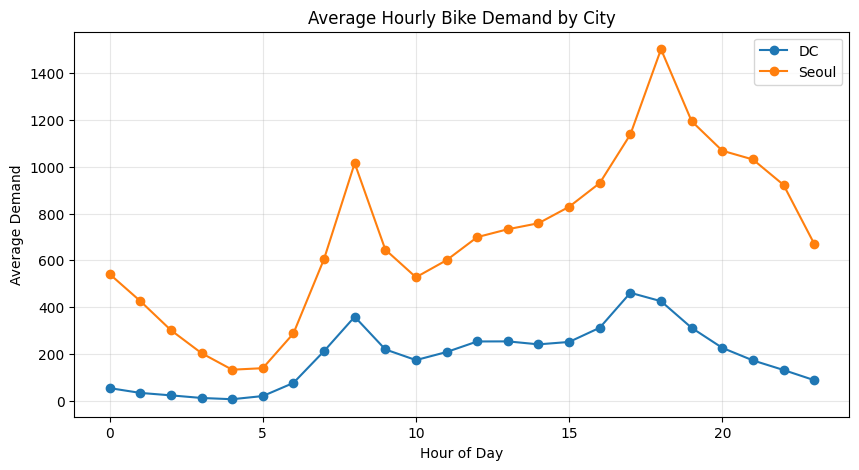

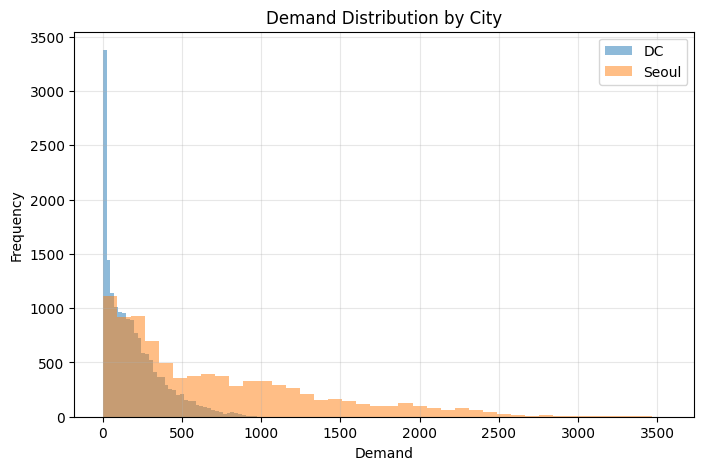

In [18]:
# Step 3: Quick EDA (2 plots)

# 1) Average hourly demand by city
hourly = combined.copy()
hourly["hour"] = hourly["datetime"].dt.hour

avg_hourly = hourly.groupby(["city", "hour"])["demand"].mean().reset_index()

plt.figure(figsize=(10, 5))
for city_name in avg_hourly["city"].unique():
    subset = avg_hourly[avg_hourly["city"] == city_name]
    plt.plot(subset["hour"], subset["demand"], marker="o", label=city_name)

plt.title("Average Hourly Bike Demand by City")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2) Demand distribution by city
plt.figure(figsize=(8, 5))
for city_name in combined["city"].unique():
    subset = combined[combined["city"] == city_name]["demand"]
    plt.hist(subset, bins=40, alpha=0.5, label=city_name)

plt.title("Demand Distribution by City")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Phase 4: Feature Engineering

1. Build model-ready features from time: hour, day_of_week, month, is_weekend
2. Encode city as a numeric column (city_code) for baseline modeling.
3. Fill missing rainfall for DC so the model has no missing values.
4. Create: x = input features, y = target demand

In [25]:
# Step 4.1: Feature engineering from datetime
model_df = combined.copy()

# Time features
model_df["hour"] = model_df["datetime"].dt.hour
model_df["day_of_week"] = model_df["datetime"].dt.dayofweek  # 0=Mon, 6=Sun
model_df["month"] = model_df["datetime"].dt.month
model_df["is_weekend"] = model_df["day_of_week"].isin([5, 6]).astype(int)

# Keep city as numeric for baseline model (DC=0, Seoul=1)
model_df["city_code"] = model_df["city"].map({"DC": 0, "Seoul": 1})

# Replace missing rainfall in DC with 0 for baseline
model_df["rainfall"] = model_df["rainfall"].fillna(0)

# Encode holiday text/number values into binary
holiday_norm = model_df["holiday"].astype(str).str.strip().str.lower()
model_df["holiday_bin"] = holiday_norm.isin(["1", "true", "holiday", "yes"]).astype(int)

# Encode season consistently across both datasets
season_norm = model_df["season"].astype(str).str.strip().str.lower()
season_map = {
    "1": 1, "2": 2, "3": 3, "4": 4,
    "winter": 1, "spring": 2, "summer": 3, "autumn": 4, "fall": 4,
}
model_df["season_code"] = season_norm.map(season_map)
if model_df["season_code"].isna().any():
    print("Unmapped season values:", sorted(model_df.loc[model_df["season_code"].isna(), "season"].astype(str).unique()))
    raise ValueError("Found season values that are not mapped.")
model_df["season_code"] = model_df["season_code"].astype(int)

# Final baseline feature set
feature_cols = [
    "temperature", "humidity", "windspeed", "rainfall",
    "holiday_bin", "season_code", "hour", "day_of_week", "month", "is_weekend", "city_code"
]

X = model_df[feature_cols].copy()
y = model_df["demand"].copy()

print("Model table shape:", model_df.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nMissing values in features:")
print(X.isna().sum())

model_df.head()

Model table shape: (26139, 16)
Feature matrix shape: (26139, 11)
Target shape: (26139,)

Missing values in features:
temperature    0
humidity       0
windspeed      0
rainfall       0
holiday_bin    0
season_code    0
hour           0
day_of_week    0
month          0
is_weekend     0
city_code      0
dtype: int64


,datetime,demand,temperature,humidity,windspeed,holiday,season,rainfall,city,hour,day_of_week,month,is_weekend,city_code,holiday_bin,season_code
0,2011-01-01 00:00:00,16,0.24,0.81,0.0,0,1,0.0,DC,0,5,1,1,0,0,1
1,2011-01-01 01:00:00,40,0.22,0.80,0.0,0,1,0.0,DC,1,5,1,1,0,0,1
2,2011-01-01 02:00:00,32,0.22,0.80,0.0,0,1,0.0,DC,2,5,1,1,0,0,1
3,2011-01-01 03:00:00,13,0.24,0.75,0.0,0,1,0.0,DC,3,5,1,1,0,0,1
4,2011-01-01 04:00:00,1,0.24,0.75,0.0,0,1,0.0,DC,4,5,1,1,0,0,1


In [26]:
# Step 5: Baseline forecasting model (Linear Regression)

import sys
import subprocess

# Ensure scikit-learn is installed in the same notebook kernel environment
subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Random split baseline (we will do time-based split later)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Baseline Linear Regression Results")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))

results_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

results_df.head()

Baseline Linear Regression Results
MAE: 191.148
RMSE: 299.787


,actual,predicted
0,13,79.198492
1,209,461.771419
2,343,183.472776
3,234,258.400711
4,59,302.858242
